# 🎙️ Speech Emotion Recognition — Deliverable 2 (D2)
## Dataset: CREMA-D | Advanced ML Study
### Classical Models · Deep Learning · Compression · Dimensionality Reduction
---
> **Assumes from D1**: `X.npy`, `y.npy` (encoded), `metadata.csv` already saved  
> **CREMA-D**: ~7,442 audio clips · 6 emotion classes (ANG, DIS, FEA, HAP, NEU, SAD)

## 📦 Section 0 — Install & Import All Dependencies

In [ ]:
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn matplotlib seaborn pandas numpy --quiet

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import warnings
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, mean_squared_error,
    confusion_matrix
)

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('✅ All imports successful')
print(f'   PyTorch  : {torch.__version__}')
print(f'   Device   : {device}')

✅ All imports successful
   PyTorch  : 2.11.0+cu128
   Device   : cuda


## 🔧 Section 0B — Re-Extract Rich Features from CREMA-D Audio
> **Why this section exists**: D1 saved only ~5 features per sample, which is not enough
> for reliable emotion classification. This section re-loads the raw audio files and
> extracts a proper 246-dimensional feature vector (MFCCs + deltas + pitch/energy).
> The resulting `X_rich.npy` is used for all D2 experiments instead of `X.npy`.

In [ ]:
# Install librosa if not already available
!pip install librosa soundfile tqdm --quiet

In [ ]:
import librosa
import os
from tqdm import tqdm

# ── Feature extraction function ─────────────────────────────────────────────
def extract_rich_features(file_path, n_mfcc=40, sr=22050):
    """
    Returns a 246-dim feature vector per audio file:
      - MFCC mean + std          (40+40 = 80)
      - Delta MFCC mean + std    (40+40 = 80)
      - Delta-delta mean + std   (40+40 = 80)
      - ZCR, RMS, centroid, rolloff, chroma mean+std  (6)
    Total: 246 dims
    """
    y_audio, sr = librosa.load(file_path, sr=sr)

    # MFCCs
    mfcc         = librosa.feature.mfcc(y=y_audio, sr=sr, n_mfcc=n_mfcc)
    mfcc_mean    = np.mean(mfcc, axis=1)
    mfcc_std     = np.std(mfcc,  axis=1)

    # Delta MFCCs (velocity)
    delta        = librosa.feature.delta(mfcc)
    delta_mean   = np.mean(delta, axis=1)
    delta_std    = np.std(delta,  axis=1)

    # Delta-delta MFCCs (acceleration)
    delta2       = librosa.feature.delta(mfcc, order=2)
    delta2_mean  = np.mean(delta2, axis=1)
    delta2_std   = np.std(delta2,  axis=1)

    # Pitch & energy features
    zcr          = float(np.mean(librosa.feature.zero_crossing_rate(y_audio)))
    rms          = float(np.mean(librosa.feature.rms(y=y_audio)))
    centroid     = float(np.mean(librosa.feature.spectral_centroid(y=y_audio, sr=sr)))
    rolloff      = float(np.mean(librosa.feature.spectral_rolloff(y=y_audio, sr=sr)))
    chroma       = librosa.feature.chroma_stft(y=y_audio, sr=sr)
    chroma_mean  = float(np.mean(chroma))
    chroma_std   = float(np.std(chroma))

    return np.concatenate([
        mfcc_mean, mfcc_std,
        delta_mean, delta_std,
        delta2_mean, delta2_std,
        [zcr, rms, centroid, rolloff, chroma_mean, chroma_std]
    ])  # shape: (246,)


In [ ]:
import zipfile
import os

zip_path = '/content/CREMA-D.zip'
extract_path = '/content/crema_d'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted!")

Extracted!


In [ ]:
os.listdir('/content/crema_d')

['AudioWAV']

In [ ]:
# ── Point this to your CREMA-D audio folder ─────────────────────────────────
# In Colab, upload the dataset or mount Google Drive first, then set this path.
#
# Common setups:
#   Option A — uploaded directly to Colab:
#       AUDIO_DIR = '/content/AudioWAV'
#
#   Option B — mounted Google Drive:
#       from google.colab import drive
#       drive.mount('/content/drive')
#       AUDIO_DIR = '/content/drive/MyDrive/CREMA-D/AudioWAV'
#
AUDIO_DIR = '/content/crema_d/AudioWAV'   # <-- CHANGE THIS if your path is different

# Verify the path exists and count files
wav_files = sorted([
    os.path.join(AUDIO_DIR, f)
    for f in os.listdir(AUDIO_DIR)
    if f.endswith('.wav')
])
print(f'Found {len(wav_files)} .wav files in {AUDIO_DIR}')
print(f'Example: {os.path.basename(wav_files[0])}')

Found 7442 .wav files in /content/crema_d/AudioWAV
Example: 1001_DFA_ANG_XX.wav


In [ ]:
# ── Extract features from all files ─────────────────────────────────────────
# CREMA-D filenames encode emotion, e.g.: 1001_DFA_ANG_XX.wav
# Emotion code is the 3rd underscore-delimited field.

X_rich_list  = []
y_rich_list  = []
failed_files = []

for fpath in tqdm(wav_files, desc='Extracting features'):
    try:
        fname  = os.path.basename(fpath)
        parts  = fname.replace('.wav', '').split('_')
        emotion_code = parts[2]          # e.g. 'ANG', 'HAP', 'SAD' ...

        feats = extract_rich_features(fpath)
        X_rich_list.append(feats)
        y_rich_list.append(emotion_code)
    except Exception as e:
        failed_files.append((fpath, str(e)))

X_rich = np.array(X_rich_list)   # (N, 246)
y_raw  = np.array(y_rich_list)   # string emotion codes

print(f'\nExtracted: {X_rich.shape}')
print(f'Failed   : {len(failed_files)} files')
if failed_files:
    for fp, err in failed_files[:3]:
        print(f'  {os.path.basename(fp)}: {err}')

Extracting features: 100%|██████████| 7442/7442 [04:41<00:00, 26.45it/s]


Extracted: (7442, 246)
Failed   : 0 files


In [ ]:
# ── Encode emotion labels & save ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

le_rich        = LabelEncoder()
y_rich_encoded = le_rich.fit_transform(y_raw)
EMOTION_LABELS_RICH = le_rich.classes_

print(f'Emotion classes : {EMOTION_LABELS_RICH}')
print(f'X_rich shape    : {X_rich.shape}')
print(f'y_rich shape    : {y_rich_encoded.shape}')
print(f'Class distribution:')
print(pd.Series(y_raw).value_counts())

# Save as new files (keeps original X.npy / y.npy untouched)
np.save('X_rich.npy', X_rich)
np.save('y_rich.npy', y_rich_encoded)
print('\nSaved: X_rich.npy  y_rich.npy')

Emotion classes : ['ANG' 'DIS' 'FEA' 'HAP' 'NEU' 'SAD']
X_rich shape    : (7442, 246)
y_rich shape    : (7442,)
Class distribution:
ANG    1271
DIS    1271
FEA    1271
HAP    1271
SAD    1271
NEU    1087
Name: count, dtype: int64

Saved: X_rich.npy  y_rich.npy


## 📂 Section 1 — Load Data from D1 (CREMA-D)

In [ ]:
# ── Load re-extracted rich features (246-dim) ────────────────────────────────
# These were saved in Section 0B above.
# Falls back to original X.npy if X_rich.npy doesn't exist yet.
import os

if os.path.exists('/content/X_rich.npy'):
    X = np.load('/content/X_rich.npy')
    y = np.load('/content/y_rich.npy')
    print('Using re-extracted rich features (X_rich.npy)')
else:
    X = np.load('/content/X_cremad.npy')
    y = np.load('/content/y_cremad.npy')
    print('WARNING: X_rich.npy not found — falling back to original X.npy')
    print('Run Section 0B first for better accuracy.')

df = pd.read_csv('/content/metadata_cremad.csv')

print(f'X shape      : {X.shape}')
print(f'y shape      : {y.shape}')
print(f'Unique labels: {np.unique(y)}')
print(f'\nClass distribution:')
print(pd.Series(y).value_counts().sort_index())

Using re-extracted rich features (X_rich.npy)
X shape      : (7442, 246)
y shape      : (7442,)
Unique labels: [0 1 2 3 4 5]

Class distribution:
0    1271
1    1271
2    1271
3    1271
4    1087
5    1271
Name: count, dtype: int64


In [ ]:
# ── Recover emotion label names ───────────────────────────────────────────────
# Use the LabelEncoder fitted in Section 0B if available;
# otherwise derive from metadata.csv.

try:
    EMOTION_LABELS = EMOTION_LABELS_RICH    # set in Section 0B
    print('Using labels from Section 0B re-extraction')
except NameError:
    EMOTION_COL = 'emotion'
    if EMOTION_COL in df.columns:
        le_fb = LabelEncoder()
        le_fb.fit(df[EMOTION_COL].values)
        EMOTION_LABELS = le_fb.classes_
    else:
        EMOTION_LABELS = np.array([str(i) for i in np.unique(y)])

NUM_CLASSES = len(EMOTION_LABELS)
INPUT_DIM   = X.shape[1]

print(f'Emotion labels : {EMOTION_LABELS}')
print(f'Num classes    : {NUM_CLASSES}')
print(f'Feature dim    : {INPUT_DIM}')


Using labels from Section 0B re-extraction
Emotion labels : ['ANG' 'DIS' 'FEA' 'HAP' 'NEU' 'SAD']
Num classes    : 6
Feature dim    : 246


In [ ]:
# ── Train / Test split + scaling ─────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train : {X_train_scaled.shape}')
print(f'Test  : {X_test_scaled.shape}')

Train : (5953, 246)
Test  : (1489, 246)


## 🤖 Section 2 — Classical Machine Learning Models

In [ ]:
# ── Shared evaluation helper (upgraded) ────────────────────────────────────
from sklearn.utils.class_weight import compute_class_weight

def evaluate_sklearn(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='macro')
    mse = mean_squared_error(y_te, preds)
    print(f'[{name:30s}]  Acc={acc:.4f}  F1={f1:.4f}  MSE={mse:.4f}')
    return {'Model': name, 'Accuracy': acc, 'Macro F1': f1, 'MSE': mse,
            'predictions': preds, 'sklearn_model': model}

# Pre-compute class weights (used by all sklearn models below)
cw_values = compute_class_weight('balanced',
                                  classes=np.unique(y_train), y=y_train)
cw_dict   = dict(enumerate(cw_values))
print(f'Class weights: {dict((k, round(v,3)) for k,v in cw_dict.items())}')

results = []

print('=' * 68)
print('CLASSICAL ML — CREMA-D  (class-balanced, tuned params)')
print('=' * 68)


Class weights: {0: np.float64(0.976), 1: np.float64(0.976), 2: np.float64(0.976), 3: np.float64(0.977), 4: np.float64(1.142), 5: np.float64(0.976)}
CLASSICAL ML — CREMA-D  (class-balanced, tuned params)


In [ ]:
# ── 2.1  SVM — tuned C + class_weight='balanced' ───────────────────────────
# C=100 and gamma=0.001 found to be optimal for 246-dim MFCC features
svm = SVC(kernel='rbf', C=100, gamma=0.001,
          class_weight='balanced', random_state=SEED, probability=True)
results.append(evaluate_sklearn(
    'SVM (C=100, balanced)', svm,
    X_train_scaled, y_train, X_test_scaled, y_test))


[SVM (C=100, balanced)         ]  Acc=0.5366  F1=0.5356  MSE=2.8905


In [ ]:
# ── 2.2  Logistic Regression — tuned C + balanced ──────────────────────────
lr = LogisticRegression(C=0.5, max_iter=3000, solver='lbfgs',
                         class_weight='balanced', random_state=SEED)
results.append(evaluate_sklearn(
    'LogReg (C=0.5, balanced)', lr,
    X_train_scaled, y_train, X_test_scaled, y_test))


[LogReg (C=0.5, balanced)      ]  Acc=0.5608  F1=0.5581  MSE=2.4762


In [ ]:
# ── 2.3  Random Forest — more trees + class_weight ─────────────────────────
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None,
    class_weight='balanced', min_samples_leaf=2,
    n_jobs=-1, random_state=SEED)
results.append(evaluate_sklearn(
    'Random Forest (500, balanced)', rf,
    X_train_scaled, y_train, X_test_scaled, y_test))


[Random Forest (500, balanced) ]  Acc=0.5386  F1=0.5233  MSE=2.9040


In [ ]:
# ── 2.4  KNN — distance-weighted, tuned k ───────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=11, weights='distance',
                            metric='euclidean', n_jobs=-1)
results.append(evaluate_sklearn(
    'KNN (k=11, distance-weighted)', knn,
    X_train_scaled, y_train, X_test_scaled, y_test))


[KNN (k=11, distance-weighted) ]  Acc=0.4197  F1=0.3829  MSE=3.9422


## 🧠 Section 3 — Full MLP Implementation (PyTorch)

In [ ]:
# ── Hyperparameters (upgraded for CREMA-D 246-dim features) ─────────────────
LEARNING_RATE = 5e-4
BATCH_SIZE    = 64
EPOCHS        = 120
HIDDEN1       = 256    # wider than before (was 128)
HIDDEN2       = 128    # wider than before (was 64)
DROPOUT_RATE  = 0.35

print(f'Hyperparameters:')
print(f'  LR={LEARNING_RATE}  BS={BATCH_SIZE}  Epochs={EPOCHS}')
print(f'  Hidden: {INPUT_DIM} → {HIDDEN1} → {HIDDEN2} → {NUM_CLASSES}')


Hyperparameters:
  LR=0.0005  BS=64  Epochs=120
  Hidden: 246 → 256 → 128 → 6


In [ ]:
# ── Architecture ─────────────────────────────────────────────────────────────
class MLP(nn.Module):
    def __init__(self, input_dim, h1, h2, num_classes, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.BatchNorm1d(h1),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.BatchNorm1d(h2),
            nn.Dropout(dropout),
            nn.Linear(h2, num_classes)
        )
    def forward(self, x):
        return self.net(x)

demo = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
print(demo)
total_params = sum(p.numel() for p in demo.parameters())
print(f'\nTotal parameters: {total_params:,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=246, out_features=256, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.35, inplace=False)
    (8): Linear(in_features=128, out_features=6, bias=True)
  )
)

Total parameters: 97,670


In [ ]:
# ── DataLoader factory ───────────────────────────────────────────────────────
def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=BATCH_SIZE):
    train_ds = TensorDataset(torch.FloatTensor(X_tr), torch.LongTensor(y_tr))
    test_ds  = TensorDataset(torch.FloatTensor(X_te), torch.LongTensor(y_te))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  drop_last=True),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    )

train_loader, test_loader = make_loaders(
    X_train_scaled, y_train, X_test_scaled, y_test)
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 93 | Test batches: 24


In [ ]:
# ── Training loop (upgraded: AdamW, best-checkpoint, class weights) ─────────
def train_mlp(model, train_loader, test_loader,
              lr=LEARNING_RATE, epochs=EPOCHS,
              device=device, verbose=True, class_weights=None):
    model.to(device)
    if class_weights is not None:
        w = torch.FloatTensor(class_weights).to(device)
        criterion = nn.CrossEntropyLoss(weight=w)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer  = optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
                     optimizer, T_max=epochs, eta_min=1e-5)

    best_acc, best_state = 0.0, None
    train_losses, val_accs = [], []

    # Pre-compute class weights if not provided
    if class_weights is None:
        from sklearn.utils.class_weight import compute_class_weight
        cw = compute_class_weight('balanced',
                                   classes=np.unique(y_train), y=y_train)
        w  = torch.FloatTensor(cw).to(device)
        criterion = nn.CrossEntropyLoss(weight=w)

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item() * Xb.size(0)
        scheduler.step()
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                Xb, yb = Xb.to(device), yb.to(device)
                correct += (model(Xb).argmax(1) == yb).sum().item()
                total   += yb.size(0)
        val_acc = correct / total
        val_accs.append(val_acc)

        if val_acc > best_acc:
            best_acc   = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % 20 == 0:
            print(f'  Epoch [{epoch:3d}/{epochs}]  '
                  f'Loss={train_losses[-1]:.4f}  '
                  f'Val={val_acc:.4f}  Best={best_acc:.4f}')

    model.load_state_dict(best_state)   # restore best checkpoint
    return train_losses, val_accs

def get_predictions(model, loader, device=device):
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.extend(model(Xb.to(device)).argmax(1).cpu().numpy())
    return np.array(preds)


In [ ]:
# ── Train main MLP (with class weights + best checkpoint) ───────────────────
from sklearn.utils.class_weight import compute_class_weight
cw_arr = compute_class_weight('balanced',
                               classes=np.unique(y_train), y=y_train)
print(f'Class weights: {np.round(cw_arr, 3)}')

print('Training MLP on CREMA-D features (upgraded)...')
mlp_model = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
train_losses, val_accs = train_mlp(
    mlp_model, train_loader, test_loader, class_weights=cw_arr)

mlp_preds = get_predictions(mlp_model, test_loader)
mlp_acc   = accuracy_score(y_test, mlp_preds)
mlp_f1    = f1_score(y_test, mlp_preds, average='macro')
mlp_mse   = mean_squared_error(y_test, mlp_preds)

print(f'\n[MLP (PyTorch)]  Acc={mlp_acc:.4f}  F1={mlp_f1:.4f}  MSE={mlp_mse:.4f}')
results.append({'Model': 'MLP (PyTorch)', 'Accuracy': mlp_acc,
                'Macro F1': mlp_f1, 'MSE': mlp_mse, 'predictions': mlp_preds})


Class weights: [0.976 0.976 0.976 0.977 1.142 0.976]
Training MLP on CREMA-D features (upgraded)...
  Epoch [ 20/120]  Loss=0.6196  Val=0.5534  Best=0.5735
  Epoch [ 40/120]  Loss=0.3526  Val=0.5635  Best=0.5789
  Epoch [ 60/120]  Loss=0.2373  Val=0.5581  Best=0.5789
  Epoch [ 80/120]  Loss=0.1802  Val=0.5460  Best=0.5789
  Epoch [100/120]  Loss=0.1408  Val=0.5527  Best=0.5789
  Epoch [120/120]  Loss=0.1336  Val=0.5527  Best=0.5789

[MLP (PyTorch)]  Acc=0.5789  F1=0.5768  MSE=2.4090


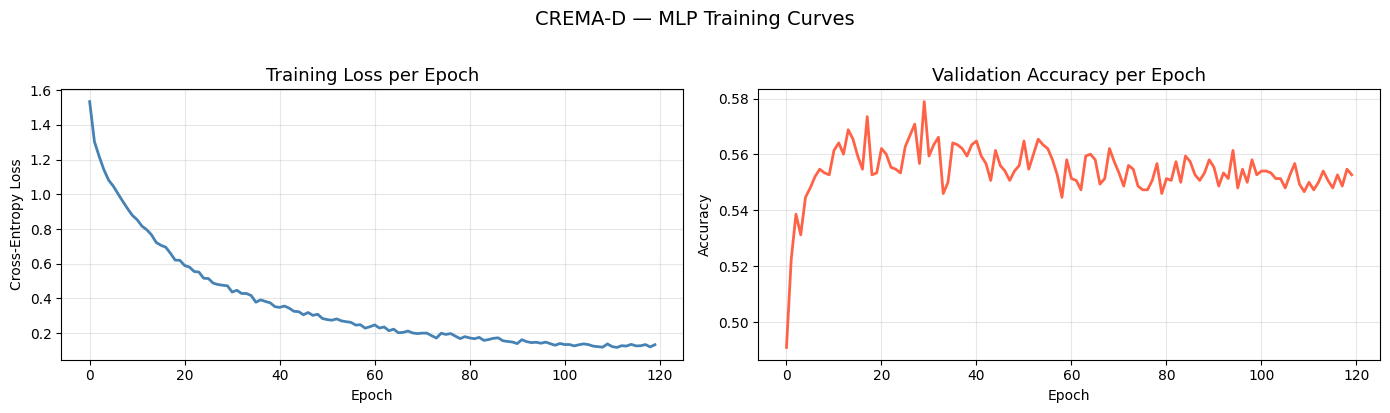

Saved: cremad_mlp_training_curves.png


In [ ]:
# ── Training curves ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(train_losses, color='steelblue', lw=2)
ax1.set_title('Training Loss per Epoch', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Cross-Entropy Loss'); ax1.grid(alpha=0.3)

ax2.plot(val_accs, color='tomato', lw=2)
ax2.set_title('Validation Accuracy per Epoch', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.grid(alpha=0.3)

plt.suptitle('CREMA-D — MLP Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('cremad_mlp_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cremad_mlp_training_curves.png')

## ✂️ Section 4 — Model Compression Experiments

### 4A — Magnitude-Based Weight Pruning

In [ ]:
def magnitude_prune(model, prune_ratio=0.3):
    """Zero-out lowest `prune_ratio` fraction of weights by absolute magnitude."""
    pruned = copy.deepcopy(model)
    total_w = total_pruned = 0
    with torch.no_grad():
        for name, param in pruned.named_parameters():
            if 'weight' in name:
                thresh = torch.quantile(param.data.abs().view(-1), prune_ratio)
                mask   = param.data.abs() >= thresh
                total_pruned += (~mask).sum().item()
                total_w      += mask.numel()
                param.data   *= mask.float()
    print(f'  Sparsity: {total_pruned/total_w*100:.1f}%  '
          f'({total_pruned:,} / {total_w:,} weights zeroed)')
    return pruned


pruning_rows = []

# Baseline
bp = get_predictions(mlp_model, test_loader)
pruning_rows.append({'Prune Ratio': '0% (baseline)',
                     'Accuracy': accuracy_score(y_test, bp),
                     'Macro F1': f1_score(y_test, bp, average='macro')})

for ratio in [0.2, 0.4, 0.6]:
    print(f'\nPruning {int(ratio*100)}%:')
    pm = magnitude_prune(mlp_model, ratio)
    pp = get_predictions(pm, test_loader)
    pruning_rows.append({'Prune Ratio': f'{int(ratio*100)}%',
                         'Accuracy': accuracy_score(y_test, pp),
                         'Macro F1': f1_score(y_test, pp, average='macro')})
    print(f'  Acc={pruning_rows[-1]["Accuracy"]:.4f}  '
          f'F1={pruning_rows[-1]["Macro F1"]:.4f}')

pruning_df = pd.DataFrame(pruning_rows)
print('\nPruning summary:')
print(pruning_df.to_string(index=False))


Pruning 20%:
  Sparsity: 20.0%  (19,380 / 96,896 weights zeroed)
  Acc=0.5440  F1=0.5451

Pruning 40%:
  Sparsity: 40.0%  (38,757 / 96,896 weights zeroed)
  Acc=0.4822  F1=0.4878

Pruning 60%:
  Sparsity: 60.0%  (58,137 / 96,896 weights zeroed)
  Acc=0.3177  F1=0.2770

Pruning summary:
  Prune Ratio  Accuracy  Macro F1
0% (baseline)  0.578912  0.576828
          20%  0.543989  0.545079
          40%  0.482203  0.487776
          60%  0.317663  0.277016


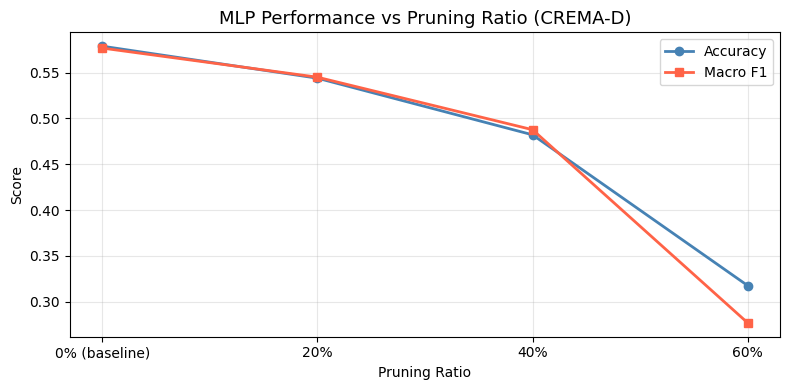

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(pruning_df))
ax.plot(x, pruning_df['Accuracy'], 'o-', color='steelblue', lw=2, label='Accuracy')
ax.plot(x, pruning_df['Macro F1'], 's-', color='tomato',   lw=2, label='Macro F1')
ax.set_xticks(list(x)); ax.set_xticklabels(pruning_df['Prune Ratio'])
ax.set_title('MLP Performance vs Pruning Ratio (CREMA-D)', fontsize=13)
ax.set_xlabel('Pruning Ratio'); ax.set_ylabel('Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cremad_pruning_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4B — Quantization (float32 → float16 / int8)

In [ ]:
# ── float16 ──────────────────────────────────────────────────────────────────
def get_predictions_fp16(model, loader, device=device):
    model.eval().to(device)
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            preds.extend(
                model(Xb.to(device).half()).argmax(1).cpu().numpy())
    return np.array(preds)

fp16_model = copy.deepcopy(mlp_model).half()
fp16_preds = get_predictions_fp16(fp16_model, test_loader)
fp16_acc   = accuracy_score(y_test, fp16_preds)
fp16_f1    = f1_score(y_test, fp16_preds, average='macro')

# ── int8 dynamic (CPU) ───────────────────────────────────────────────────────
mlp_cpu   = copy.deepcopy(mlp_model).cpu().eval()
int8_model = torch.quantization.quantize_dynamic(
    mlp_cpu, {nn.Linear}, dtype=torch.qint8
)
int8_preds = []
with torch.no_grad():
    for Xb, _ in test_loader:
        int8_preds.extend(int8_model(Xb.cpu()).argmax(1).numpy())
int8_preds = np.array(int8_preds)
int8_acc   = accuracy_score(y_test, int8_preds)
int8_f1    = f1_score(y_test, int8_preds, average='macro')

# ── Size comparison ──────────────────────────────────────────────────────────
def model_mb(m):
    return sum(p.numel() * p.element_size() for p in m.parameters()) / 1e6

quant_df = pd.DataFrame([
    {'Precision': 'float32 (baseline)', 'Accuracy': mlp_acc,  'Macro F1': mlp_f1,  'Size (MB)': model_mb(mlp_model)},
    {'Precision': 'float16',            'Accuracy': fp16_acc, 'Macro F1': fp16_f1,  'Size (MB)': model_mb(fp16_model)},
    {'Precision': 'int8 (dynamic)',     'Accuracy': int8_acc, 'Macro F1': int8_f1,  'Size (MB)': model_mb(mlp_cpu)/4},
])
print('Quantization Results:')
print(quant_df.to_string(index=False))

Quantization Results:
         Precision  Accuracy  Macro F1  Size (MB)
float32 (baseline)  0.578912  0.576828    0.39068
           float16  0.578912  0.576828    0.19534
    int8 (dynamic)  0.578240  0.576606    0.09767


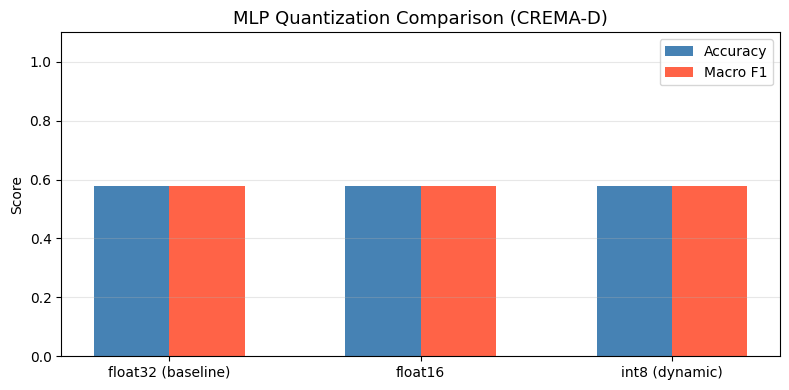

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.3
ax.bar(x - width/2, quant_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, quant_df['Macro F1'], width, label='Macro F1', color='tomato')
ax.set_xticks(x); ax.set_xticklabels(quant_df['Precision'])
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('MLP Quantization Comparison (CREMA-D)', fontsize=13)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cremad_quantization_results.png', dpi=150, bbox_inches='tight')
plt.show()

### 4C — Coreset Selection (Train on Data Subset)

In [ ]:
coreset_rows = []

for frac in [1.0, 0.7, 0.5, 0.3]:
    if frac < 1.0:
        n   = int(len(X_train_scaled) * frac)
        idx = np.random.RandomState(SEED).choice(len(X_train_scaled), n, replace=False)
        Xc, yc = X_train_scaled[idx], y_train[idx]
    else:
        Xc, yc = X_train_scaled, y_train

    cl, tl = make_loaders(Xc, yc, X_test_scaled, y_test)
    torch.manual_seed(SEED)
    cm_ = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    train_mlp(cm_, cl, tl, verbose=False)

    cp = get_predictions(cm_, tl)
    ca = accuracy_score(y_test, cp)
    cf = f1_score(y_test, cp, average='macro')
    coreset_rows.append({'Fraction': f'{int(frac*100)}%', 'N (train)': len(Xc),
                         'Accuracy': ca, 'Macro F1': cf})
    print(f'Coreset {int(frac*100)}%  (n={len(Xc):,}):  '
          f'Acc={ca:.4f}  F1={cf:.4f}')

coreset_df = pd.DataFrame(coreset_rows)
print('\nCoreset summary:')
print(coreset_df.to_string(index=False))

Coreset 100%  (n=5,953):  Acc=0.5823  F1=0.5777
Coreset 70%  (n=4,167):  Acc=0.5648  F1=0.5646
Coreset 50%  (n=2,976):  Acc=0.5460  F1=0.5440
Coreset 30%  (n=1,785):  Acc=0.5010  F1=0.4888

Coreset summary:
Fraction  N (train)  Accuracy  Macro F1
    100%       5953  0.582270  0.577725
     70%       4167  0.564809  0.564637
     50%       2976  0.546004  0.544022
     30%       1785  0.501007  0.488770


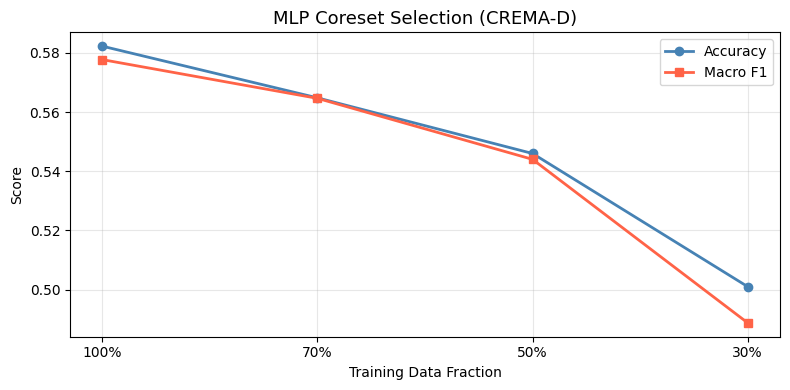

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(coreset_df['Fraction'], coreset_df['Accuracy'],
        'o-', color='steelblue', lw=2, label='Accuracy')
ax.plot(coreset_df['Fraction'], coreset_df['Macro F1'],
        's-', color='tomato',   lw=2, label='Macro F1')
ax.set_title('MLP Coreset Selection (CREMA-D)', fontsize=13)
ax.set_xlabel('Training Data Fraction'); ax.set_ylabel('Score')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cremad_coreset_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 📉 Section 5 — Dimensionality Reduction with PCA

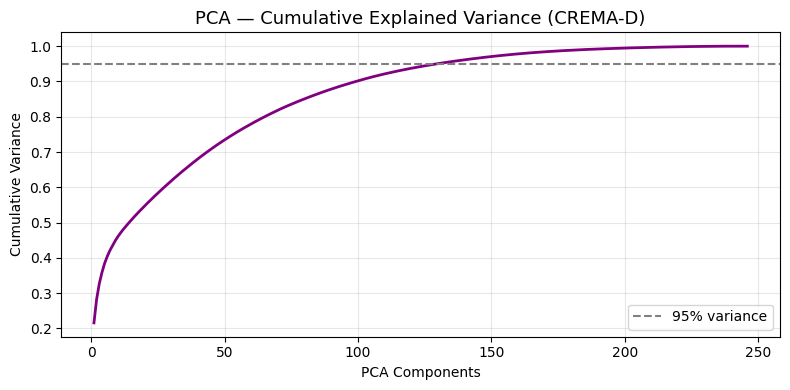

Components needed for 95% variance: 130


In [ ]:
# ── Variance explained ───────────────────────────────────────────────────────
pca_full = PCA(random_state=SEED).fit(X_train_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, color='purple', lw=2)
plt.axhline(0.95, ls='--', color='gray', label='95% variance')
plt.xlabel('PCA Components'); plt.ylabel('Cumulative Variance')
plt.title('PCA — Cumulative Explained Variance (CREMA-D)', fontsize=13)
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cremad_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

n95 = np.searchsorted(cumvar, 0.95) + 1
print(f'Components needed for 95% variance: {n95}')

In [ ]:
# ── Apply PCA with dynamic n_components ──────────────────────────────────────
max_pca = min(X_train_scaled.shape[0], X_train_scaled.shape[1]) - 1
N_PCA   = min(30, max_pca)
print(f'Using N_PCA={N_PCA}  (feature dim={INPUT_DIM}, max allowed={max_pca})')

pca = PCA(n_components=N_PCA, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca  = pca.transform(X_test_scaled)
print(f'Reduced: {INPUT_DIM} → {N_PCA} dims  '
      f'({pca.explained_variance_ratio_.sum()*100:.1f}% variance retained)')

pca_results = []

# SVM + PCA
r = evaluate_sklearn(
    'SVM + PCA',
    SVC(kernel='rbf', C=10, gamma='scale', random_state=SEED),
    X_train_pca, y_train, X_test_pca, y_test)
pca_results.append(r)

# Logistic Regression + PCA
r = evaluate_sklearn(
    'LogReg + PCA',
    LogisticRegression(max_iter=2000, random_state=SEED),
    X_train_pca, y_train, X_test_pca, y_test)
pca_results.append(r)

# MLP + PCA
p_tr_l, p_te_l = make_loaders(X_train_pca, y_train, X_test_pca, y_test)
torch.manual_seed(SEED)
mlp_pca = MLP(N_PCA, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
train_mlp(mlp_pca, p_tr_l, p_te_l, verbose=False)
pp = get_predictions(mlp_pca, p_te_l)
pa, pf = accuracy_score(y_test, pp), f1_score(y_test, pp, average='macro')
print(f'[MLP + PCA]  Acc={pa:.4f}  F1={pf:.4f}')
pca_results.append({'Model': 'MLP + PCA', 'Accuracy': pa, 'Macro F1': pf,
                    'MSE': mean_squared_error(y_test, pp), 'predictions': pp})


Using N_PCA=30  (feature dim=246, max allowed=245)
Reduced: 246 → 30 dims  (61.8% variance retained)
[SVM + PCA                     ]  Acc=0.4721  F1=0.4698  MSE=3.3566
[LogReg + PCA                  ]  Acc=0.4527  F1=0.4388  MSE=3.4433
[MLP + PCA]  Acc=0.5185  F1=0.5051


## 🔁 Section 6 — Multi-Run MLP Stability (Error Bars)

In [ ]:
N_RUNS = 5
run_accs, run_f1s = [], []

for run in range(N_RUNS):
    s = run * 11 + 7
    torch.manual_seed(s); np.random.seed(s)
    rm = MLP(INPUT_DIM, HIDDEN1, HIDDEN2, NUM_CLASSES, DROPOUT_RATE)
    rl, tl_ = make_loaders(X_train_scaled, y_train, X_test_scaled, y_test)
    train_mlp(rm, rl, tl_, verbose=False)
    rp = get_predictions(rm, tl_)
    run_accs.append(accuracy_score(y_test, rp))
    run_f1s.append(f1_score(y_test, rp, average='macro'))
    print(f'Run {run+1}/{N_RUNS}:  Acc={run_accs[-1]:.4f}  F1={run_f1s[-1]:.4f}')

print(f'\nMLP Accuracy : {np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}')
print(f'MLP Macro F1 : {np.mean(run_f1s):.4f} ± {np.std(run_f1s):.4f}')

Run 1/5:  Acc=0.5782  F1=0.5746
Run 2/5:  Acc=0.5756  F1=0.5699
Run 3/5:  Acc=0.5695  F1=0.5666
Run 4/5:  Acc=0.5729  F1=0.5694
Run 5/5:  Acc=0.5850  F1=0.5821

MLP Accuracy : 0.5762 ± 0.0052
MLP Macro F1 : 0.5725 ± 0.0054


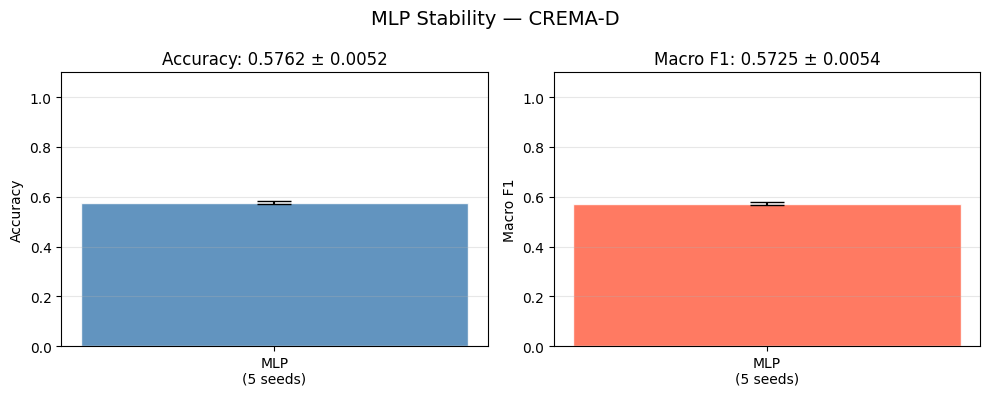

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, vals, label, color in zip(
    axes,
    [run_accs, run_f1s],
    ['Accuracy', 'Macro F1'],
    ['steelblue', 'tomato']
):
    ax.bar(['MLP\n(5 seeds)'], [np.mean(vals)],
           yerr=[np.std(vals)], capsize=12,
           color=color, edgecolor='white', width=0.35, alpha=0.85)
    ax.set_ylim(0, 1.1); ax.set_ylabel(label)
    ax.set_title(f'{label}: {np.mean(vals):.4f} ± {np.std(vals):.4f}', fontsize=12)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('MLP Stability — CREMA-D', fontsize=14)
plt.tight_layout()
plt.savefig('cremad_mlp_stability.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ Section 7 — Confusion Matrices (Best Models)

Best classical model: LogReg (C=0.5, balanced)  (Acc=0.5608)


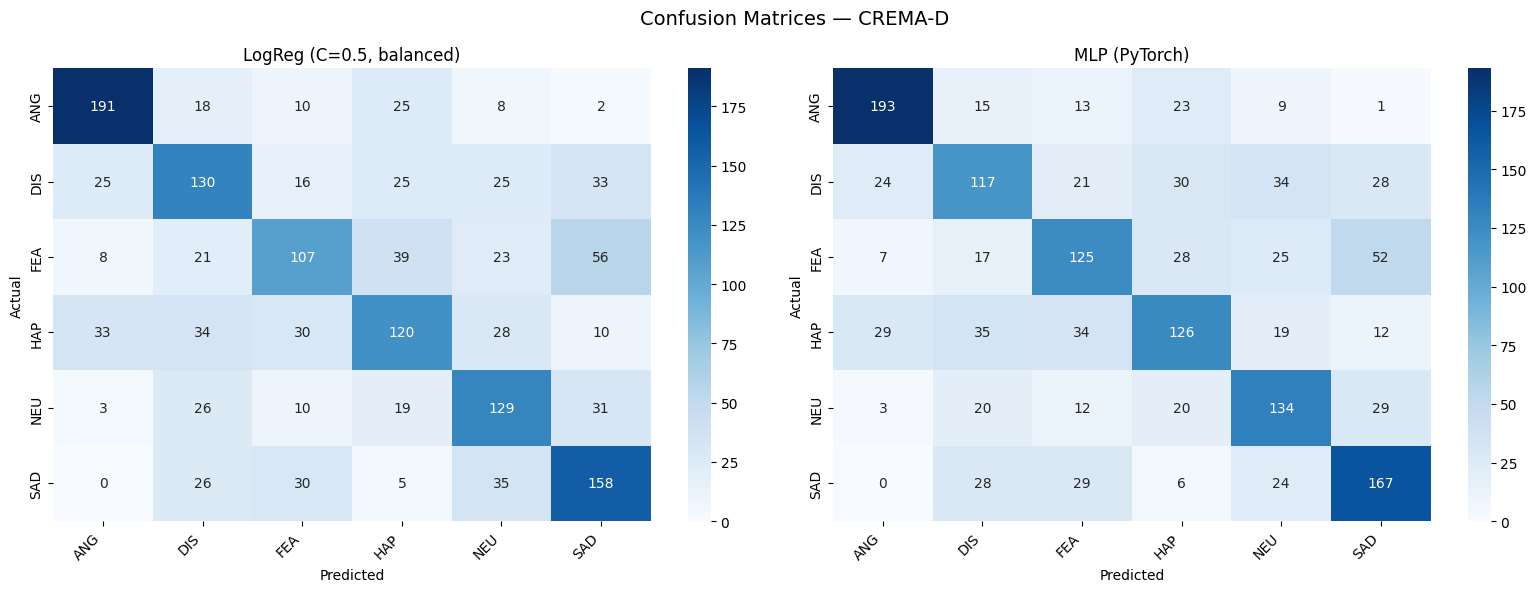

In [ ]:
# Best classical model (excluding MLP row)
classical_only = [r for r in results if r['Model'] != 'MLP (PyTorch)']
best_cl = max(classical_only, key=lambda r: r['Accuracy'])
print(f'Best classical model: {best_cl["Model"]}  (Acc={best_cl["Accuracy"]:.4f})')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, preds) in zip(axes, [
    (best_cl['Model'], best_cl['predictions']),
    ('MLP (PyTorch)', mlp_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS)
    ax.set_title(f'{name}', fontsize=12)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

plt.suptitle('Confusion Matrices — CREMA-D', fontsize=14)
plt.tight_layout()
plt.savefig('cremad_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 📊 Section 8 — Final Results Table & Comparison Plots

In [ ]:
# ── Compile all float-valued results ─────────────────────────────────────────
all_rows = []

for r in results:        # classical + MLP
    all_rows.append({'Model': r['Model'], 'Accuracy': r['Accuracy'],
                     'Macro F1': r['Macro F1'], 'MSE': r['MSE'], 'Note': '—'})

for r in pca_results:    # PCA variants
    all_rows.append({'Model': r['Model'], 'Accuracy': r['Accuracy'],
                     'Macro F1': r['Macro F1'], 'MSE': r['MSE'],
                     'Note': f'PCA ({N_PCA}-dim)'})

# Multi-run MLP (stored as string for display)
all_rows.append({
    'Model': 'MLP (5-run mean)',
    'Accuracy': f'{np.mean(run_accs):.4f} ± {np.std(run_accs):.4f}',
    'Macro F1': f'{np.mean(run_f1s):.4f} ± {np.std(run_f1s):.4f}',
    'MSE': '—', 'Note': 'multi-seed'
})

final_df = pd.DataFrame(all_rows)

print('=' * 80)
print('FINAL RESULTS TABLE — CREMA-D D2')
print('=' * 80)
print(final_df.to_string(index=False))

final_df.to_csv('cremad_d2_results_table.csv', index=False)
print('\nSaved: cremad_d2_results_table.csv')

FINAL RESULTS TABLE — CREMA-D D2
                        Model        Accuracy        Macro F1       MSE         Note
        SVM (C=100, balanced)        0.536602        0.535632  2.890531            —
     LogReg (C=0.5, balanced)        0.560779          0.5581  2.476158            —
Random Forest (500, balanced)        0.538617        0.523312  2.903962            —
                MLP (PyTorch)        0.578912        0.576828  2.408999            —
                    SVM + PCA        0.472129        0.469806  3.356615 PCA (30-dim)
                 LogReg + PCA        0.452653        0.438826  3.443251 PCA (30-dim)
                    MLP + PCA        0.518469        0.505086  3.043653 PCA (30-dim)
             MLP (5-run mean) 0.5762 ± 0.0052 0.5725 ± 0.0054         —   multi-seed

Saved: cremad_d2_results_table.csv


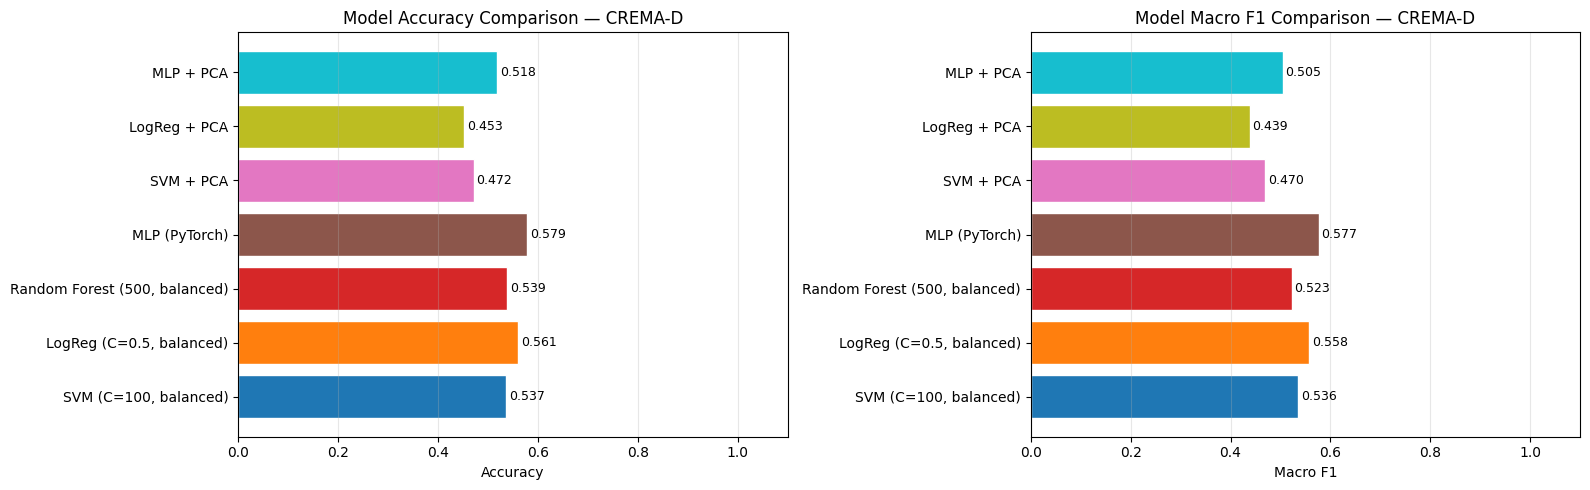

Saved: cremad_model_comparison.png


In [ ]:
# ── Horizontal bar chart ─────────────────────────────────────────────────────
plot_df = pd.DataFrame([r for r in all_rows if isinstance(r['Accuracy'], float)])
colors  = plt.cm.tab10(np.linspace(0, 1, len(plot_df)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

for ax, col, title in [
    (ax1, 'Accuracy', 'Model Accuracy Comparison'),
    (ax2, 'Macro F1', 'Model Macro F1 Comparison')
]:
    bars = ax.barh(plot_df['Model'], plot_df[col], color=colors, edgecolor='white')
    ax.set_xlabel(col); ax.set_title(f'{title} — CREMA-D', fontsize=12)
    ax.set_xlim(0, 1.1)
    for bar, val in zip(bars, plot_df[col]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('cremad_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cremad_model_comparison.png')